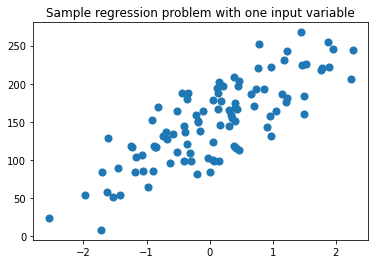

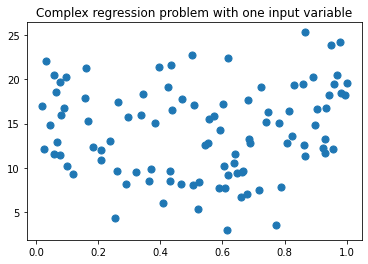

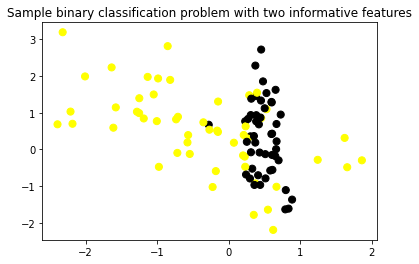

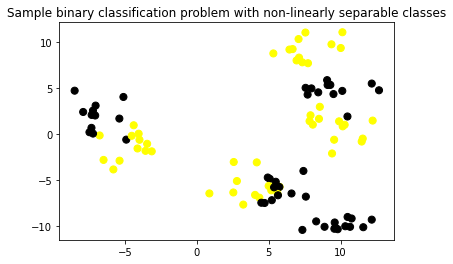

In [3]:
%run "Datasets.ipynb"

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [11]:
#use Synthetic dataset with 1 feature 
#is there no need to scale the features in case of regression or is scaling not being done because dataset is synthetic and already scaled? 
X_R1_train, X_R1_test, y_R1_train, y_R1_test = train_test_split(X_R1, y_R1, random_state =3)

In [17]:
linearRegressor=LinearRegression()

#Trained Linear Regression Classifier 
linearRegression = linearRegressor.fit(X=X_R1_train, y =y_R1_train)

print("Coefficient w :", linearRegression.coef_)
print("R-squared Score of Training Data:", linearRegression.score(X_R1_train, y_R1_train))
print("Intercept: ", linearRegression.intercept_)
print("R-squared Score of Test  Data:", linearRegression.score(X_R1_test, y_R1_test))


Coefficient w : [42.19144124]
R-squared Score of Training Data: 0.6413698349133939
Intercept:  148.5311649398092
R-squared Score of Test  Data: 0.6038632207001153


In [20]:
import matplotlib.pyplot as plt

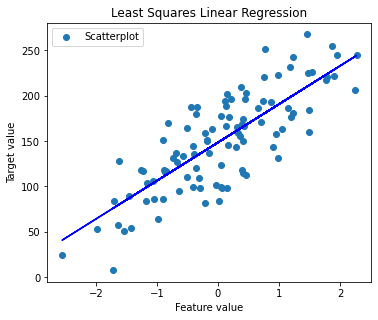

In [49]:
figure_1 =plt.figure(figsize =(5,4))
axes_1 = figure_1.add_axes([0.1,0.1,0.9,0.9])
axes_1.set_xlabel("Feature value")
axes_1.set_ylabel("Target value")
axes_1.set_title("Least Squares Linear Regression")
axes_1.scatter(X_R1, y_R1, marker ='o', label ="Scatterplot" )
#axes_1.plot(X_R1, y_R1, label ="Scatterplot" )
axes_1.legend(loc=0)

axes_1.plot( X_R1, linearRegression.coef_*X_R1+linearRegression.intercept_, 'b-' , label ="Linear Regression Line")
#figure_1.add_subplot( 1, 5,1)

#### RIdge Regresssion

In [65]:
from sklearn.linear_model import Ridge
#test train split
X_train, X_test, y_train, y_test = train_test_split(X_crime, y_crime, random_state = 0)

#train the classifier with the training dataset 
ridge_regression = Ridge(alpha=1).fit( X =X_train, y = y_train)
print( ridge_regression.coef_) 
print(ridge_regression.intercept_)
print("R-squared score of training set data {:.2f} ".format(ridge_regression.score(X_train, y_train)))
print("R-squared score of test set data {:.2f} ".format(ridge_regression.score(X_test, y_test)))

TypeError: fit() got an unexpected keyword argument 'random_state'

#### RIdge Regresssion with Feature Normalization

In [80]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import MinMaxScaler
#test train split
X_train, X_test, y_train, y_test = train_test_split(X_crime, y_crime, random_state = 0)
scaler = MinMaxScaler()
#This estimator scales and translates each feature individually such that it is in the given range on the training set, e.g. between zero and one.
X_train_scaled =scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

#train the classifier with the training dataset 
ridge_regression = Ridge(alpha=1).fit( X =X_train_scaled, y = y_train)
print( ridge_regression.coef_) 
print(ridge_regression.intercept_)
print("R-squared score of training set data {:.2f} ".format(ridge_regression.score(X_train_scaled, y_train)))
print("R-squared score of test set data {:.2f} ".format(ridge_regression.score(X_test_scaled, y_test)))
print("No of non-zero weight features: ", sum(ridge_regression.coef_!=0))

[ 7.54103315e+00  6.05533534e+01  4.95857048e+01 -5.06762423e+02
 -1.05074422e+02 -8.90875685e+01 -1.47861600e+01  1.08287224e+02
 -3.35407905e+00 -2.07215353e+02  4.05544113e+01 -4.09980554e+02
  1.76784594e+02  2.95169733e+01 -2.43571550e+02  3.20442712e+01
  1.09728123e+02  8.47949301e+01 -1.37514400e+02 -5.07132696e+02
  3.75662960e+02  3.27927188e+01 -8.74184067e+01  2.51366206e+02
 -1.78240455e+02 -1.32406198e+02  9.21475863e+01  2.41486320e+02
  3.09855655e+02  3.73686225e+02 -1.93578201e+02 -9.05316742e+01
  2.78740533e+02 -3.24734991e+02 -9.23148836e+02  3.14649682e-01
 -3.31087275e+01  1.58055639e+02 -4.11267101e+02  4.86011642e+01
  1.10593134e+03 -3.03665711e+02  8.08130727e+01 -4.71340777e+01
 -1.29103577e+02  7.65538294e+01 -1.19250913e+02 -7.31803132e+01
  8.02849167e+01  1.17467073e+02  1.20725443e+02 -5.53129475e+02
 -9.48578551e+00 -2.46241792e+02  2.82947909e+02 -1.17727326e+02
 -7.27197215e+01 -2.11822158e+02  6.83607310e+02  2.98988800e+02
  1.26897969e+02  6.77393

#### Affect of changing the regularization parameter alpha

In [77]:
for thisalpha in (1, 10, 20, 50, 100, 1000): 
    ridge_regressor = Ridge(alpha = thisalpha).fit(X_train_scaled, y_train)
    #print( ridge_regression.coef_) 
    #print(ridge_regression.intercept_)
    print("Alpha: {},R-squared score of training set data : {:.2f}, test set : {:.2f} \n".format(thisalpha, ridge_regressor.score(X_train_scaled, y_train), ridge_regressor.score(X_test_scaled, y_test)))

Alpha: 1,R-squared score of training set data : 0.66, test set : 0.61 

Alpha: 10,R-squared score of training set data : 0.63, test set : 0.63 

Alpha: 20,R-squared score of training set data : 0.61, test set : 0.62 

Alpha: 50,R-squared score of training set data : 0.58, test set : 0.59 

Alpha: 100,R-squared score of training set data : 0.55, test set : 0.56 

Alpha: 1000,R-squared score of training set data : 0.31, test set : 0.31 

